# Regresión Lineal

En esta unidad aprenderemos sobre la regresión en su variante más general: la regresión lineal. Emplearemos una base de datos sobre ingresos de una empresa y buscaremos los determinantes asociados a mayores ingresos.

La regresión responde a la pregunta ¿Cómo el cambio de una variable afecta el valor de otra variable?

La regresión es un método muy flexible asociado con las preguntas de asociación y causalidad de nuestros fenómenos por estudiar.

Para esta semana trabajaremos con el caso más simple: la regresión lineal. Por lineal hablamos del caso donde nuestra variable objetivo (o dependiente) es contínua y la relación entre esta y los atributos (o variables independientes) es mediante una combinación lineal de los últimos.
La regresión permite generalizarse a múltiples casos, por lo que entender su caso canónico nos deja bien preparados para modelos más flexibles como los Generalized Lineal Models, modelos no paramétricos, multinivel, efectos fijos y Generalized Additive Models, por nombrar algunos.

Se dice regresión lineal simple a aquella que tiene un regresor como atributo (o variable independiente). Más adelante hablaremos de la regresión lineal múltiple, aquella que tiene más de un regresor como atributo (o variable independiente).

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
# import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
# import statsmodels.formula.api as smf
import seaborn as sns
# import warnings
import lec5_graphs as gfx

plt.rcParams["figure.figsize"] = (9, 4) # Tamaño gráficos

In [3]:
df = pd.read_csv('earnings.csv')
df.head()

,Unnamed: 0,earn,height1,height2,sex,race,hisp,ed,yearbn,height,age,age_category,eth,male
0,3,50000.0,6,2,1,1,2,16,45,74,45,2,3,1
1,4,60000.0,5,6,2,1,2,16,32,66,58,3,3,0
2,5,30000.0,5,4,2,1,2,16,61,64,29,1,3,0
3,9,51000.0,5,3,2,1,2,17,51,63,39,2,3,0
4,10,9000.0,5,4,2,1,2,15,64,64,26,1,3,0


Solicitemos las principales estadísticas descriptivas para cada variable con `describe()` . El método nos entrega información sobre:

- count: La cantidad de observaciones en la muestra.
- mean: La media aritmética de cada variable.
- std: La desviación estandar de cada variable.
- min: El valor mínimo observado de la variable en la muestra.
- 25%: El rango intercuartil inferior de la variable en la muestra.
- 50%: La mediana de la variable en la muestra.
- 75%: El rango intercuartil superior de la variable en la muestra.
- max: El valor máximo observado de la variable en la muestra.

In [4]:
df.describe()

,Unnamed: 0,earn,height1,height2,sex,race,hisp,ed,yearbn,height,age,age_category,eth,male
count,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000
mean,1029.446143,19981.433770,5.128821,5.050218,1.622999,1.167394,1.941776,13.353712,48.848617,66.596070,41.151383,1.861718,2.780204,0.377001
std,587.765286,19781.488482,0.360261,3.173719,0.484812,0.641772,0.234252,2.440269,15.542169,3.803324,15.542169,0.814886,0.628077,0.484812
min,3.000000,0.000000,4.000000,0.000000,1.000000,1.000000,1.000000,3.000000,3.000000,58.000000,18.000000,1.000000,1.000000,0.000000
25%,520.250000,6000.000000,5.000000,3.000000,1.000000,1.000000,2.000000,12.000000,39.000000,64.000000,29.000000,1.000000,3.000000,0.000000
50%,1027.500000,16000.000000,5.000000,5.000000,2.000000,1.000000,2.000000,13.000000,52.000000,66.000000,38.000000,2.000000,3.000000,0.000000
75%,1536.750000,28000.000000,5.000000,8.000000,2.000000,1.000000,2.000000,15.000000,61.000000,69.000000,51.000000,3.000000,3.000000,1.000000
max,2029.000000,200000.000000,6.000000,11.000000,2.000000,9.000000,2.000000,18.000000,72.000000,77.000000,87.000000,3.000000,4.000000,1.000000


`describe()` es útil, pero para las variables categóricas es mejor ver sus frecuencias. Para ello, utilizaremos `.value_counts()` en cada variable.

In [5]:
# separemos todas las variables que son categóricas
categorical_columns = ['sex', 'race', 'hisp', 'age_category', 'eth', 'male']
# iniciamos un loop para cada variable categórica donde:
for cat in categorical_columns:
    # imprimimos el nombre
    print("\n",cat)
    # solicitamos la frecuencia relativa de cada categoría dentro de la variable
    print(df[cat].value_counts())
    # solicitamos el porcentaje de la frecuencia relativa
    print((df[cat].value_counts()/len(df[cat])))


 sex
sex
2    856
1    518
Name: count, dtype: int64
sex
2    0.622999
1    0.377001
Name: count, dtype: float64

 race
race
1    1216
2     126
3      17
4      10
9       5
Name: count, dtype: int64
race
1    0.885007
2    0.091703
3    0.012373
4    0.007278
9    0.003639
Name: count, dtype: float64

 hisp
hisp
2    1294
1      80
Name: count, dtype: int64
hisp
2    0.941776
1    0.058224
Name: count, dtype: float64

 age_category
age_category
1    564
2    436
3    374
Name: count, dtype: int64
age_category
1    0.410480
2    0.317322
3    0.272198
Name: count, dtype: float64

 eth
eth
3    1144
1     126
2      77
4      27
Name: count, dtype: int64
eth
3    0.832606
1    0.091703
2    0.056041
4    0.019651
Name: count, dtype: float64

 male
male
0    856
1    518
Name: count, dtype: int64
male
0    0.622999
1    0.377001
Name: count, dtype: float64


Nuestro objetivo es ver la asociación entre los ingresos generados y la altura de cada individuo.

Primero generemos un diagrama de dispersión con `sns.jointplot()`. El gráfico entregará información sobre la distribución de cada unoa de las variables, así como un diagrama de dispersión entre ambas.

La sintáxis de la función es: `sns.jointplot(data=<DataFrame>, x=<var. independiente>, y=<var. dependiente>)`

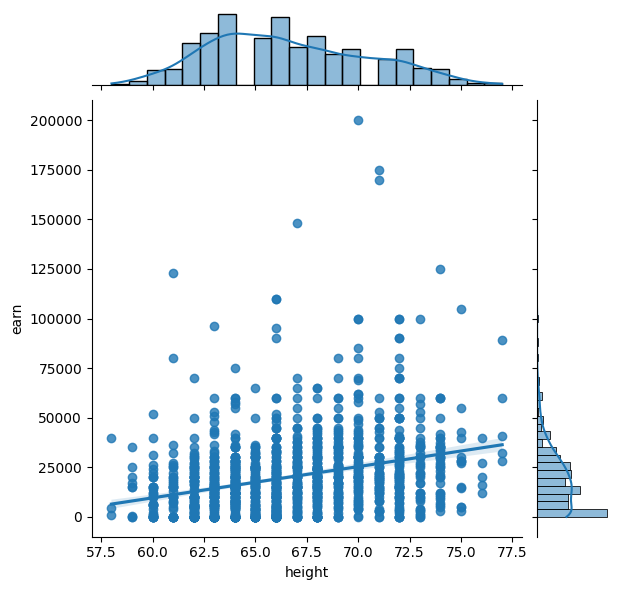

In [6]:
sns.jointplot(data=df, x='height', y='earn', kind='reg');

El diagrama ejecutado entrega la siguiente información:

1. El diagrama nos informa de una asociación positiva entre ambas variables. Una salvedad a rescatar es que la asociación entre ambas es relativamente débil (su r de Pearson es de .30).
2. La baja correlación puede ser explicada por la distribución de las variables. Mientras que height persenta una distribución relativamente normal, earn está fuertemente sesgada hacia valores bajos.
3. Otro motivo que pueda estar influyendo levemente es que, si nos fijamos en los valores que toma la variable height de la tabla entregada por el método describe, los valores al parecer fueron redondeados (min, max y los cuartiles son numeros enteros), esta es la razón también de que se vean 'franjas' en el gráfico de dispersión.

Para examinar la normalidad de nuestras variables, statsmodels presenta un gráfico de normalidad Q-Q (Quantile - Quantile).

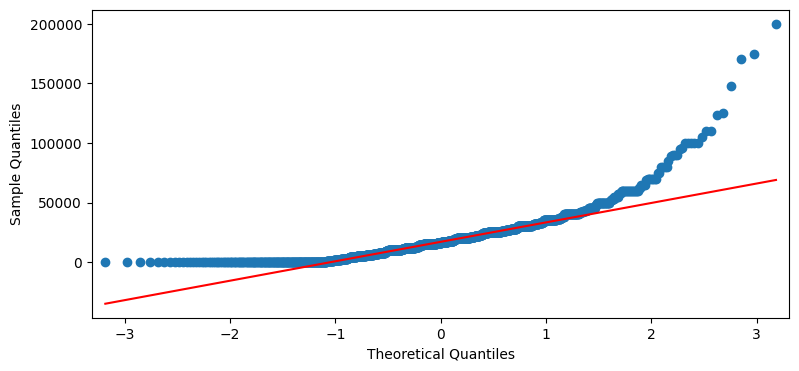

In [7]:
sm.qqplot(df['earn'],line='q');

En el gráfico podemos observar que la variable escapa de los valores esperados en los extremos de la distribución. Ésto es un punto a considerar en la modelación que veremos más adelante.

El gráfico Q-Q compara la distribución empírica de nuestra variable en el eje Y (con la etiqueta 'Sample Quantities') contra la distribución esperada de la variable (bajo la etiqueta 'Theoretical Quantities').

La opción `line='q'` permite trazar una línea entre cantidades observadas y esperadas en los cuantiles de nuestra variable. Una distribución normal tendrá la mayoría de sus datos cercanos a la línea.

Si ejecutamos el mismo diagnóstico para `height`, el resultado es distinto.

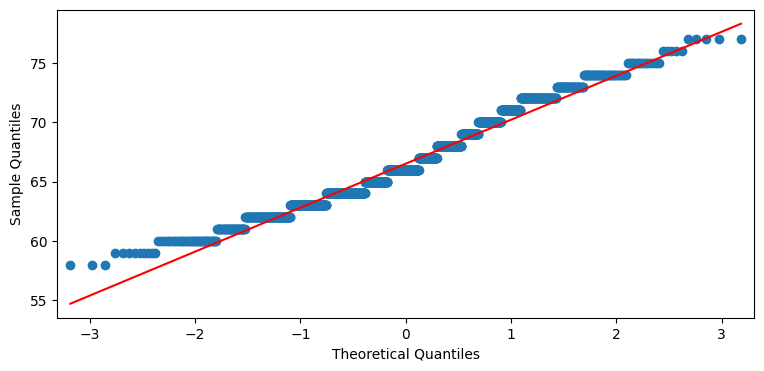

In [8]:
sm.qqplot(df['height'], line='q');

Una vez realizado las principales exploraciones, nuestro objetivo es generar una explicación plausible de cómo la altura de los individuos afecta los niveles de ingreso en promedio. Para ello utilizaremos la regresión lineal, un método que permite extraer información sobre cómo una variable independiente contribuye en una variable dependiente.

La regresión lineal es un método que resume cómo los valores de una variable objetivo de característica numérica varían en subpoblaciones definidas por una función lineal de atributos. Esta definición proviene de Gelman & Hill (2007) y pone énfasis en la característica descriptiva de la regresión por sobre la idea causal.

Si bien la regresión puede utilizarse para representar asociaciones causales, preferimos enfatizar la capacidad de presentar comparaciones de promedios entre dos subpoblaciones. Así somos explícitos sobre las limitantes de la regresión al no considerar los supuestos de inferencia causal.

Nuestro primer modelo a ejecutar tendrá la siguiente especificación:

$$earn = \beta_0 + \beta_1 \cdot height + \epsilon$$

donde buscamos generar un modelo que explique la varianza de `earn` en función a `height`. En la ecuación agregamos un $\epsilon_i$ para tomar en cuenta la incertidumbre de nuestro modelo. Volveremos a este punto cuando discutamos los supuestos que le dan validez al modelo (Teorema de Gauss-Markov).

El objetivo del algoritmo es generar estimaciones respecto al intercepto (expresado como $\beta_0$, que representa el punto de partida de la función lineal) y de la pendiente (expresada como $\beta_1$, que representa la contribución de X en Y cuando X cambia en 1 unidad).

Para entender la validez de nuestras estimaciones mediante Mínimos Cuadrados Ordinarios, es necesario estudiar someramente cómo se generan.

La obtención paramétrica de los descansa en el método de mínimos cuadrados (MCO).

El objetivo del MCO es encontrar un estimador que reduzca la distancia residual entre los valores predichos y sus correlatos observados.
Bajo este enfoque, se asume que los parámetros verdaderos (o poblacionales) son desconocidos y buscamos generar aproximaciones.
Si tenemos un modelo con la siguiente forma:

$$Y_i = \beta_0 + \beta_1 \cdot X_i + \epsilon_i$$

buscamos un estimador que minimice la suma de errores cuadráticos:

$$\beta = \arg \min_{\beta \in \mathbb{R}^d} \mathbb{E}[(y_i - X_i^T \beta)^2]$$

$$ = \sum_{i=0}^N (Y_t-(\beta_0 + \beta_1 \cdot X))^2$$

**Observación**: MCO es un método intuitivo y fácil de entender y programar, sin embargo, está lejos de ser perfecto, una de las más grandes debilidades de MCO es que es extremadamente sensible a valores extremos (outliers), ya sea porque los puntos $(x_i, y_i)$ son muy pequeños o demasiado grandes en comparación con el resto de la muestra, en estos casos el cuadrado de la distancia es una cantidad que puede llevar a desequilibrar por completo la recta de la regresión, los casos en que estos outliers son producto del error humano o de instrumentación pueden ser fatales para el modelo.

En la figura generada con `gfx.gauss_markov()` se presenta tres posibles estimadores candidatos para encontrar nuestro parámetro verdadero ($\beta$). Éstos difieren en sus componentes paramétricos, asumiendo que se comportan de forma asintóticamente normal $\hat{\beta_j} \sim N(\cdot)$.

- Nuestra primera estimación $\hat{\beta_1}$ tiene una media similar a nuestro parámetro verdadero, pero su varianza es grande.
- Nuestra segunda estimación $\hat{\beta_2}$ tiene una media superior al parámetro verdadero y una varianza similar a la primera estimación.
- Nuestra tercera y última estimación $\hat{\beta_3}$ tiene una media idéntica a la primera estimación, pero una menor varianza.
- En este caso, la estimación $\hat{\beta_2}$ falla en capturar el parámetro poblacional, por lo que es descartada.
- Entre la estimación $\hat{\beta_1}$ y $\hat{\beta_3}$ , ésta última satisface las condiciones de Gauss-Markov, dado que su varianza es menor y asegura que error tendrá una media menor.
- El cumplimiento de las condiciones de Gauss Markov nos asegurará que el estimador será el estimador lineal insesgado y óptimo, obteniendo el estimador eficiente dentro de la clase de estimadores lineales insesgados.

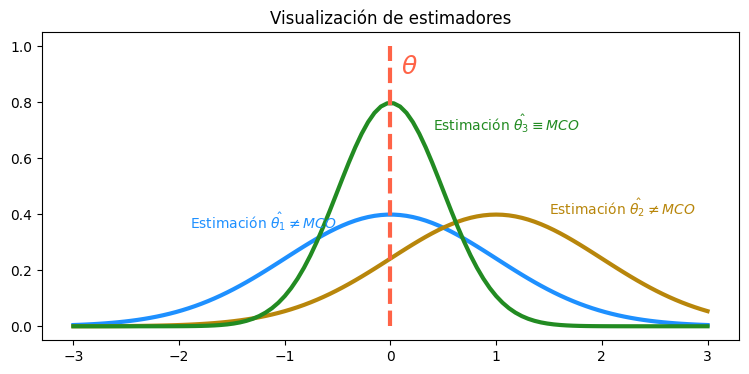

In [9]:
gfx.gauss_markov()

## ¿Cuáles son las condiciones de Gauss-Markov?

El teorema de Gauss-Markov descansa en cinco supuestos:

1. La media del error es 0 ($\mathbb{E}[\epsilon_i] = 0$): No hay sesgo sistemático de forma positiva o negativa respeto a los errores muestrales. Su media será 0 para estos casos. Surge de éste supuesto que cuando $X$ es igual a su media, $Y$ también lo será.
2. Independencia del error y las variables explicativas ($\mathbb{E}[\epsilon_i|X_i] = 0$): Los residuos no están determinados por la variable explicativa.
3. Ausencia de correlación entre los residuos ($\mathbb{E}[\epsilon_i|\epsilon_j] = 0(i\neq j)$): Los residuos de las observaciones distitnas deben ser estadísticamente independientes. La información del residuo para uno caso no debe afectar el signo o valor de los residuos para otros casos. Ante los casos de correlación existente entre los residuos, hablamos de correlación serial o correlación espacial.
4. Ausencia de correlación entre la varianza y las variables ($\mathbb{E}[\epsilon_i^2] = \text{cte} $): La varianza de los errores en cualquier valor de $X$ debe ser independiente a $X$ e $Y$.
5. Distribución normal de los errores ($\epsilon_i \sim N(0,\sigma^2)$): Se asume que los errores deben tener una distribución empírica cercana a la normal para todo el rango de $X$.

### Digresión: ¿Qué supuestos son los más relevantes?

Gelman y Hill (2007) sugieren que los supuestos se pueden ordernar de más importantes a menos importantes.
1. Validez: Los datos que analizamos deben estar relacionados a la pregunta de investigación que se busca responder. Suena obvio, pero muchas veces se obvía.
1. Aditividad y Linealidad: El supuesto más importante desde la matemática es que el componente determinístico (la ecuación) es una función lineal de los predictores.
1. Independencia de los errores: Los errores deben estar libres de correlaciones entre sí mismos y no deben afectar a las demás mediciones.
1. Normalidad de los errores: Generalmente no es problemático el tener distribuciones nonormales, puesto que se pueden aplicar transformaciones como $\log(x)$, $\sqrt{x}$, $1/x$.

## Machine Learning

Una de las principales diferencias entre la estadística, machine learning e inteligencia artificial es cómo se refieren a las variables, Mientras que en la estadística (y la tradición más académica) se habla de variables dependientes (el fenómeno a estudiar) e independientes (atributos que pueden explicar la variable dependiente), en machine learning se habla de atributos y objetivos.

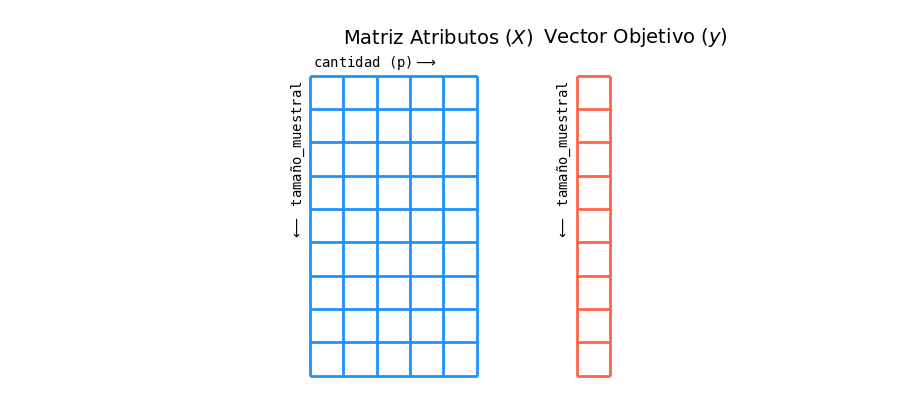

In [10]:
gfx.feature_target()

En machine learning se suele considerar la matriz de atributos ($X$) y el vector objetivo ($\hat{y}$) como entidades separadas. El por qué hace referencia a la finalidad de generar buenas predicciones a partir de la matriz de atributos, no el discriminar entre distintas variables pertenencientes a $X$.

## El flujo de trabajo desde Machine Learning

### Primer elemento: Conocer los datos

Los datos son observaciones de fenómenos empíricos. Cada uno de ellos provee información (limitada) sobre un aspecto de nuestro fenómeno a estudiar. La colección de todos los datos nos permite dar una panorámica (aún incompleta) sobre el fenómeno.

Es sano asumir que todos los datos vienen con información faltante y ruido de medición. 

### Segundo elemento: Determinar los objetivos de Trabajo

El tipo de datos a disposición limita el tipo de objetivos de trabajo.

Más que un fin en sí, los objetivos permiten fijar las preguntas de investigación.

Los objetivos de trabajo también permiten definir la arquitectura y modelos que se utilizarán.

### Tercer elemento: Diseñar e implementar los Modelos

La elección del modelo viene determinada parcialmente por los objetivos de trabajo y los datos disponibles.

Algunos elementos a considerar:

- ¿Qué esperamos como resultado?
- ¿Qué parámetros estimaremos?
- ¿Qué hiperparámetros consideraremos?

Los parámetros son aquellos elementos que se generan mediante los algoritmos o métodos de estimación. Éstos no son gobernados directamente por el investigador.

Los hiperparámetros son los elementos que se determinan por el investigador e influyen en los parámetros a estimar. Ejemplos de hiperparámetros son el porcentaje de datos que se distribuyen en los subconjuntos train y test, la inclusión de un parámetro basal como $\beta_0$, la normalización de la matriz de datos, entre otros.

## Nuestro primer modelo desde Machine Learning con `scikit-learn`

Para nuestro primer modelo utilizaremos la misma base de datos earnings.csv , donde buscaremos predecir los ingresos de individuos a partir de una serie de características registradas.

Utilizaremos `scikit-learn`, una librería diseñada para implementar modelos de minería de datos y machine learning de manera simple y efectiva. Opera con componentes de `numpy`, `scipy` y `matplotlib` para facilitar la labor del investigador.

En énfasis en la facilidad de uso, rigurosidad en el código, amplia comunidad de apoyo y buena documentación la han transformado en la principal librería de análisis enfocado a la predicción. Para más información sobre `scikit-learn`, vea la [página oficial](https://http://scikit-learn.org/).

### Paso 1: Importación de módulos

Dado la vasta cantidad de funciones en la librería, se sugiere importar los módulos específicos que utilizaremos. Esto conlleva un trabajo de identificar todos los argumentos requeridos en las funciones.

Para generar un modelo lineal necesitamos el módulo `linear_model`, que importaremos mediante `from <...> import <...>`.

Posteriormente importamos las métricas de evaluación alojadas en `sklearn.metrics`.

In [11]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

## Paso 2: Dividiendo la muestra

Otra de las características del machine learning es la divisón de las muestras entre dos grupos:

1. Training Set: Donde implementamos el modelo.
2. Test Set: Donde probamos el modelo.

El siguiente paso es poder dividir la muestra en cuatro partes. La división se puede ejemplificar en la figutra `gfx.train_testing()`. En ella generamos una división de nuestra matriz ingresada al ambiente de trabajo, teniendo en cuenta los siguientes aspectos:

1. La división debe realizarse entre una muestra que utilizaremos para generar una representación fidedigna del fenómeno.
1. Una muestra donde vamos a poner a prueba nuestra estimaciones y contrastaremos lo predecido con las observaciones reales.

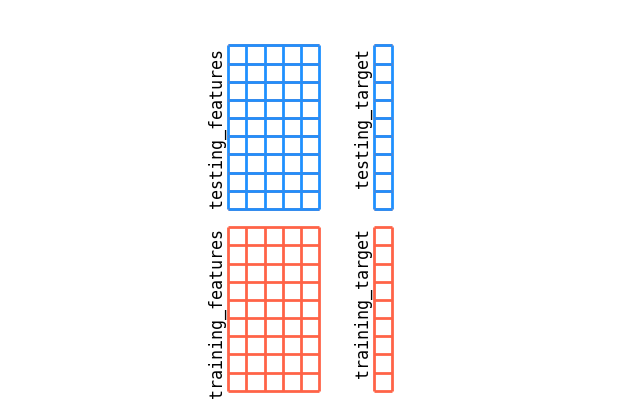

In [12]:
gfx.train_testing()

Necesitamos generar las muestras mediante el operador slice de pandas. Los cuatro grupos que
debemos crear son:

1. Matriz de Atributos en Training Set: `X_mat_train`
2. Vector Objetivo en Training Set: `y_train`
3. Matriz de Atributos en Testing Set: `X_mat_test`
4. Vector Objetivo en Testing Set: `y_test`

Para generar nuestra matriz de atributos, es necesario excluir el vector objetivo.

In [13]:
attr_mat = df.drop(['Unnamed: 0', 'earn'], axis =1)

Ahora generamos la división entre muestra de entrenamiento del modelo y muestra de prueba del modelo. Por ahora nuestra aproximación es excluir las últimas 30 filas en nuestra muestra de entrenamiento, y agregarlas a nuestra muestra de prueba. Repetimos exactamente el mismo proceso para el vector objetivo.

In [14]:
# dividir matriz de atributos
X_mat_train = attr_mat[:-30]
X_mat_test = attr_mat[-30:]

# dividir vector objetivo
y_train = df['earn'][:-30]
y_test = df['earn'][-30:]

El método que acabamos de utilizar para separar nuestros conjuntos de entrenamiento y prueba se le conoce comúnmente como 'máscara estática', la razón de esto es porque podemos ejecutar el bloque de código anterior las veces que queramos y siempre obtendremos los mismos valores en cada conjunto, en nuestro caso el conjunto de entrenamiento se compone de todas las filas excepto las últimas 30, mientras que el de pruebas se compone solo de esas 30 últimas.

En rigor, no deberíamos utilizar una máscara estática para seleccionar nuestro conjunto de entrenamiento/pruebas, deberíamos seleccionar los registros que estarán en cada conjunto de forma aleatoria, la razón de esto es porque los datos pueden estar ordenados bajo algún criterio que desconocemos (ya sea por la forma en la que se ingresaron al momento de registrarlos o, por ejemplo, producto de algún mecanismo de índice en la base de datos en la que fueron almacenados) y al entrenar nuestro modelo lo estaremos sesgando hacia esos valores. Más adelante en este mismo módulo introduciremos un método que nos provee la librería scikitlearn para obtener esta partición aleatoria. En esta ocasión utilizaremos la máscara estática para hacer el ejemplo menos aparatoso.

## Paso 3: Generar objeto y modelo

El siguiente paso es la construcción de un objeto que contenga las instrucciones a ejecutar en el modelo. Para el caso de la regresión lineal, esto se genera con la clase `LinearRegression()` del módulo linear_model .

En `scikit-learn` se defininen los hiperparámetros definidos por el usuario. Por hiperparámetros entendemos todas las instrucciones hacia el modelo que permiten definir la tolerancia, método de optimización o criterios de estimación. Esto a diferencia de los parámetros estimables que dependen exclusivamente del método de estimación.
Lo más comunes son:
- `fit_intercept` : Incluimos la estimación del intercepto ($\beta_0$) en el modelo.
<!-- - `normalize` : Reescalar cada uno de los atributos en la muestra de prueba mediante la norma euclídea. -->

In [15]:
modelo = linear_model.LinearRegression(fit_intercept=True)

Al generar el objeto con el método `LinearRegression()`. Para ello, ingresamos el training set `X_mat_train` e `y_train` en el método `.fit()` del objeto `modelo`.

Cuando pasamos los datos por la función `.fit()` no es necesario asignar de nuevo el objeto, dado que estamos generando una instancia específica de éste.

In [16]:
modelo.fit(X_mat_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Ahora `modelo` contiene información sobre los parámetros estimados como el intercepto y las pendientes para cada atributo en la matriz.

In [17]:
# imprimamos la lista de coeficientes
print("La lista de pendientes: :", modelo.coef_)

# imprimamos el intercepto del modelo
print("El intercepto del modelo es :", modelo.intercept_)

La lista de pendientes: : [   16.65006939   135.46647227 -6029.31228857  -749.4246293
  2285.85393581  2729.51444336   -33.23454676   335.26730493
    33.23454676  2215.35776999    39.36492231  6029.31228857]
El intercepto del modelo es : -39642.581649516076


Cuando solicitamos las pendientes estimadas con `modelo.coef_`, Python nos devuelve un array con cada una de ellas. Con `modelo.intercept_` obtenemos información sobre el punto de partida en las estimaciones cuando **todas nuestras variables están situadas en 0**.

### Paso 3.1: Generar predicciones

Nuestro objetivo con Machine Learning es el poder utilizar nuestras explicaciones sobre un fenómeno en datos donde no tenemos la información completa, o en datos donde no tenemos la información completa y deseamos predecir cuál sería su comportamiento, asumiendo que nuestro modelo está correcto.

El primer paso para medir el desempeño predictivo del modelo es generar nuevas predicciones en nuestra muestra de prueba. Para ello nos valemos de la función `.predict()` del modelo. 

La función `.predict()` del modelo resulta crucial de entender. La función necesita como argumento una matriz para generar predicciones. Acá es donde ingresamos la matriz de atributos del testing set.

In [18]:
earn_yhat = modelo.predict(X_mat_test)
print("La cantidad de predicciones realizadas en X_mat_test son: ", len(earn_yhat))
print("las predicciones son ", earn_yhat)

La cantidad de predicciones realizadas en X_mat_test son:  30
las predicciones son  [26511.73480161 29319.47906573 23974.62377808  5461.1796184
 15985.79575976 22977.51018177 18475.33784415 27209.5700335
 25721.83159156 40449.2596724  15625.03116587 26637.97715915
 15569.38512397 42983.40165038 24283.30932393 24379.19649299
 20999.99488436 13071.09448075 20433.10508368 -5401.27840521
 28178.80473294 27564.76155343 46239.21871922 45513.50881321
 24650.52298965 22442.96832539 31145.8839531   8493.2975025
 28269.5348291  22036.04262737]


Las predicciones de `X_mat_test` realizadas con nuestra función las guardamos en un nuevo objeto llamado `earn_yhat` (yhat hace referencia a la estimación de $\hat{y}$). Si solicitamos las nuevas observaciones, nos devolverá un array con cada uno de los puntos estimados en base a los datos de `X_mat_test`.

## Paso 4: Generar métricas

Finalmente, es necesario juzgar qué tan bien se comportó nuestro modelo al predecir los valores del vector objetivo de nuestro testing set. sklearn ofrece una serie de funciones para comparar las diferencias entre el vector objetivo de la prueba y las estimaciones del vector objetivo en base a nuestro modelo.

Utilizaremos medidas que buscan resumir qué tan grande es la diferencia entre la predicción y los datos empíricos, y el $R^2$, una medida convencional proveniente de la econometría: 

- Promedio del Error Cuadrático (Mean Squared Error): Representa la expectativa del error cuadrático. Es un indicador de calidad con valores no negativos, donde menores valores indican mejores niveles de ajuste. Una medida similar que se presenta en algunos trabajos es el Root Mean Squared Error que representa la raíz cuadrada del MSE.
  
- R-cuadrado: Representa la capacidad explicativa de nuestro conjunto de atributos en la variabilidad de nuestro vector objetivo. Tiene la misma interpretación que la enseñada desde la econometría.

Guardaremos los resultados en objetos nuevos (`m1_mse` y `m1_r2`) para su posterior uso.

In [19]:
m1_mse = np.round(mean_squared_error(y_test, earn_yhat), 2)
m1_r2 = np.round(r2_score(y_test, earn_yhat), 2)
print("Mean Squared Error: ", m1_mse)
print("R-cuadrado: ", m1_r2)

Mean Squared Error:  458564220.22
R-cuadrado:  0.19


La interpretación del R cuadrado es relativamente simple, donde esperamos que nuestra función explique en un 19% la variabilidad de nuestra variable objetivo.

El problema con el Promedio del Error Cuadrático es que necesitamos compararlo con otro modelo para ver cuál reduce más el error cuadrático. Este es un punto que volveremos a visitar al final de la lectura.

## ¿Qué fue lo que hicimos?

La regresión es un problema de aprendizaje supervisado, dado que buscamos solucionar problemas donde existen inputs y outputs que son manejados a priori por el investigador. El vector objetivo en los problemas de regresión es un vector numérico. Se dice que es un problema supervisado cuando el investigador tiene suficiente información como para calibrar el modelo (en detrimento de los modelos no supervisados donde gran parte de la responsabilidad recae en el algoritmo y en el computador). Visto de otra forma, antes de entrenar el modelo ya se conocen los valores de la variable objetivo que el modelo tiene que ser capaz de predecir (en nuestro ejemplo desde un comienzo conocíamos los valores de los salarios que queriamos que el modelo predijiese), en el aprendizaje no supervisado no tenemos la posibilidad de comparar lo que predice el modelo con la realidad y esperamos que el modelo sea capaz de encontrar estos valores/clases (por ejemplo, en problemas de clustering).

En el problema de regresión buscamos controlar la complejidad del modelo, que viene dada por la cantidad de inputs que asignamos a nuestra función. De esta manera, los contratiempos asociados a éste problema son el exceso de ajuste (presentado cuando tenemos muchos inputs que impiden
la generalización predictiva) también llamado overfitting, y la falta de ajuste (presentada cuando los inputs ingresados a la función no son suficientes como para caracterizar las predicciones dentro de la muestra) también llamado underfitting.

Dividir los datos en conjuntos de prueba y muestra, y el comparar las predicciones responde a la necesidad de probar la capacidad de generalización del modelo.

### Trueque entre sesgo y varianza

Uno de los principales criterios para analizar la capacidad de generalización del modelo es ver cómo se comportan el sesgo, la varianza y la complejidad del modelo implementado. En la figura generada con `gfx.bias_variance()`, se grafica la recta de ajuste cuando establecemos una regresión con polinomios de 1, 7 y 15 grados respectivamente. Esto genera tres situaciones:

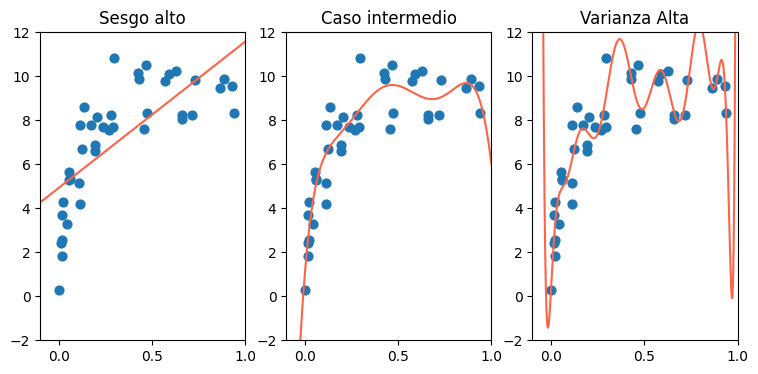

In [20]:
gfx.bias_variance()

En la figura de la izquierda encontrarmos la situación donde se presenta un sesgo alto. Por Sesgo entendemos la tendencia de un estimador de elegir un modelo incorrecto dado que utiliza supuestos incorrectos sobre el proceso generativo de los datos. Un ejemplo es si utilizamos un modelo lineal en una función cúbica. El modelo subrrepresentará los valores verdaderos en la muestra, independiente del tamaño de ésta.

En la figura de la derecha encontramos un estimador muy flexible, caracterizado por una varianza alta. Por Varianza se entiende la sensibilidad del estimador a fluctuaciones en el training set. Altos niveles de varianza en la muestra pueden generar mucho ruido en el estimador, generando predicciones fuera del rango empírico de los datos. En este caso el modelo sobrerrepresentará los valores verdaderos de la muestra.

El objetivo del aprendizaje supervisado es especificar los parámetros de forma tal de encontrar un modelo que sea lo suficientemente flexible con el caso estudiado, pero que también pueda ser extrapolado a nuevos datos y tener un buen desempeño.

### Métricas de ajuste de modelo

Para juzgar cuándo un modelo de machine learning permite generalizar predicciones, nos valemos de métricas y pruebas para su validación.

Si desde la econometría nos valemos de medidas de variabilidad explicada como el , desde machine learning nos guíamos por el principio rector de la minimización de pérdidas.

La mayoría de las métricas de un modelo de regresión buscan estimar el error promedio. Una de las más utilizadas es la mean-square error (MSE), que se define de forma:

$$MSE(\hat{f}, \text{datos}) = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{f}(x_i))^2$$

De forma alternativa también está el root-mean-square error (RMSE), que es la raíz de nuestra métrica MSE. Las diferencias entre ambas son arbitrarias, puesto que RMSE reescala MSE.

### Train-Test Split

Un problema de estimar un modelo con la muestra completa es que el cálculo del MSE depende de la cantidad de atributos ingresados en el modelo. De esta manera, el error tenderá a bajar o en el peor de los casos a mantenerse invariante.

Para machine learning el problema es estimar la función $f(\cdot)$ con un estimado de nuestra función $\hat{f}$.

Otro tema con la validación del modelo y su capacidad de generalizar predicciones, es la necesidad de ver cómo se comportan las estimaciones con nuevos datos. Este es una característica crucial de los modelos de machine learning más complejos: realizar predicciones en tiempo real de nuevos
datos ingresados.

La limitación de esto es que rara vez tenemos acceso a más datos sobre nuestro fenómeno. Las
buenas prácticas indican que para tener una aproximación sobre la generalización, podemos dividir
la muestra en dos submuestras.

Para estimar nuestra función candidata $\hat{f}$, debemos seguir lo siguiente:

1. Recolectamos una serie de datos que tengan $p\geq 1$ atributos (o variables independientes) y un vector objetivo $y$. Esta serie de datos conocida la denominamos Training Set y provee un campo empírico para implementar nuestros modelos. En la figura, éste campo se representa en los cuadrantes $X$ e $y$.
2. Con los datos a mano, elegimos un método (o múltiples métodos) para generar una estimación $\hat{f}$.
3. Utilizamos nuestro training set para entrenar o ajustar nuestra función predictiva $\hat{f}$. Por entrenar se entiende que el algoritmo/método capture información existente sobre el fenómeno.
4. Con nuestra función entrenada con los datos, buscamos generar predicciones $\hat{y} = \hat{f}(x)$ en un conjunto de datos que no fueron considerados en el conjunto de entrenamiento. En la figura, esto se representa con $\tilde{X}$. En este último conjunto de datos se conoce como Testing Set. Es necesario que éste contenga los mismos atributos que en el training set:
    - Si los datos del testing set son una submuestra proveniente de la misma fuente que el training set, se consideran como datos de validación dentro de la muestra. Éstos datos permiten comparar las predicciones de nuestro método en contraste al vector objetivo.
    - Si los datos del testing set son nuevos datos, se considera como datos de validación fuera de la muestra y permite medir el desempeño de nuestras estimaciones.

### Digresión: No free lunch theorem

Del punto 2 se desprende una máxima a considerar: no existe un método o algoritmo que provea de una solución óptima fuera de la empíricamente probada. Por ello es que siempre debemos establecer múltiples modelos para obtener un criterio informado. Éstos métodos no implican nuevos algoritmos de forma obligatoria, pero probar con distintas espeficiaciones de los parámetros e hiperparámetros. Se puede encontrar más información y detalles formales de éste teorema en http://www.no-free-lunch.org/.

Con nuestros train y test definidos, podemos medir la capacidad de reducir el error mediante MSE. 

Así calcularemos $\text{MSE}_\text{train}$ un y un $\text{MSE}_\text{test}$.

$$\text{MSE}_\text{train} = \text{MSE}(\hat{f}, \text{train}) = \frac{1}{n_\text{train}} \sum_{i\in\text{train}} (y_i - \hat{f}(x_i))^2$$

donde $n_\text{train}$ es la cantidad de observaciones en el subconjunto $\text{train}$. $\text{MSE}_\text{train}$ siempre tenderá a
bajar (o a estancarse en un valor) en la medida que la complejidad aumenta. Esto implica que no será tan útil para comparar modelos.

$$\text{MSE}_\text{test} = \text{MSE}(\hat{f}, \text{test}) = \frac{1}{n_\text{test}} \sum_{i\in\text{test}} (y_i - \hat{f}(x_i))^2$$

En este caso es el número de observaciones en el subconjunto $\text{test}$. $\text{MSE}_\text{test}$ servirá para medir ¿Qué tan bien predice nuestro modelo en datos previamiente desconocidos?.

## Algunos comportamientos de la complejidad y el tamaño de los modelos

En la figura generada con `gfx.validate_curve()` se presenta la visualización entre un puntaje (llámese bondad de ajuste, verosimilitud, etc..) y la complejidad del modelo. Mediante este gráfico buscamos evaluar cómo se comporta nuestra métrica de evaluación respecto a la complejidad del
modelo. Por complejidad del modelo se entiende de la cantidad de parámetros que se agregan al modelo para estimar.

Encontramos tres escenarios:

1. Un escenario caracterizado por una baja complejidad del modelo, que resulta en sesgos altos. Esto implica que el modelo falla en capturar de forma clara los parámetros verdaderos y la caracterización es insuficiente dado la baja cantidad de parámetros.

2. Otro escenario por una excesiva complejidad del modelo, lo que resulta en alta varianza del modelo. Bajo esta situación, el modelo genera una muy buena representación de los datos de la muestra entrenada, pero falla en replicar la generalización de las predicciones en la muestra de testing.

3. Otro escenario donde encontramos la mejor estimación del puntaje para la muestra de validación. Bajo este escenario la complejidad del modelo es óptima. Este es el objetivo del aprendizaje supervisado

Cabe destacar que mientras que en la muestra de entrenamiento el puntaje siempre incrementará en la medida que agregemos más atributos, esto será ineficiente en la medida que generaremos una función no parsimoniosa que no podremos aplicar a otro conjunto de datos.

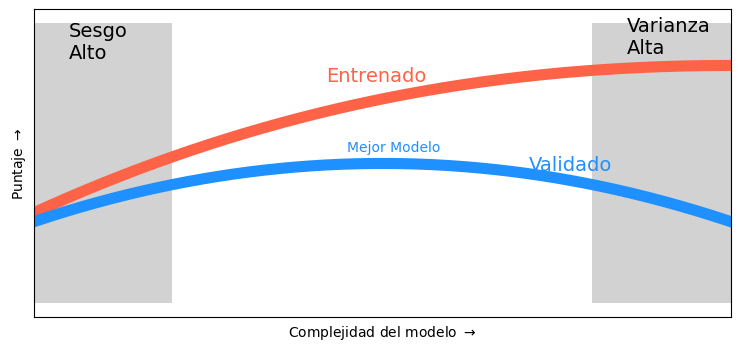

In [21]:
gfx.validate_curve()

Ya entendiendo que la cantidad de atributos agregados puede dañar la capacidad de generalizar un modelo en nuevos datos, es meritorio mencionar el efecto del tamaño muestral en el aprendizaje del modelo.

Por aprendizaje del modelo hacemos referencia a la capacidad de obtener información sobre los parámetros verdaderos a estimar.

La figura generada con `gfx.learning_curve()` muestra la relación entre el tamaño de las muestras de entrenamiento y prueba, y el puntaje a optimizar. Se aprecia que en situaciones donde el tamaño muestral del modelo entrenado es bajo, los puntajes serán sobrestimados en relación a
los puntajes de la muestra validada. 

Esperamos que ambos modelos tiendan a converger en la medida que el tamaño muestral aumenta.

Esto está asociado a lo que vimos en sesiones pasadas con los aspectos asintóticos de las variables aleatorias, donde una mayor cantidad de observaciones de una muestra permite asimilar de mejor manera las características poblacionales.

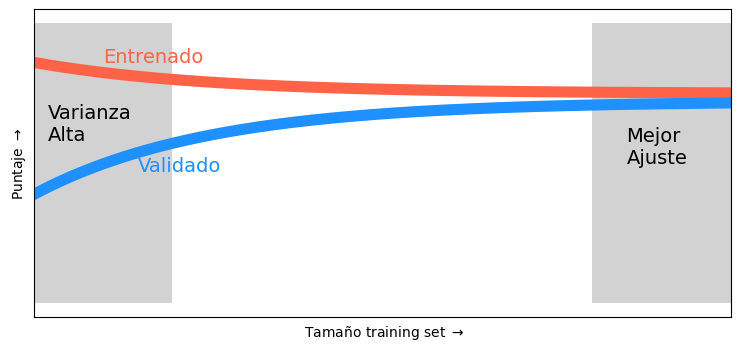

In [22]:
gfx.learning_curve()

Existen métodos más sofisticados para generar subconjuntos como la validación cruzada (crossvalidation) y la estimación 'deja-uno-afuera' (Leave-one-out) que veremos la próxima semana.

## Refactorización de nuestro modelo

### Feature engineering

Resulta que el modelo que generamos con sklearn incluye todas las variables dentro de la matriz de datos. Un inconveniente relacionado es el hecho que nuestro modelo puede que no sea el óptimo, dado que incluimos regresores que no aportan poder predictivo y utilizan grados de libertad de forma ineficiente. Nuestro objetivo es encontrar un número adecuado de regresores a incluír en nuestro modelo predictivo.

Una manera simple de determinar cuáles van a ser los principales atributos a incluir en el modelo es mediante la generación de correlaciones parciales entre cada atributo y el vector objetivo.

Este procedimiento es un ejemplo de feature engineering, el seleccionar y/o preprocesar atributos correspondiente a los datos que permiten resumir de manera precisa un modelo. Está asociado al concepto de parsimonía proveniente de la academia, donde la explicación más adecuada es
aquella que no agregue información irrelevante (el principio de la navaja de Occam).

El código de abajo es una versión extremadamente simplificada de una búsqueda de correlaciones. Para tener un algoritmo más depurado, es necesario diferenciar entre la naturaleza de las variables ingresadas y el tipo de correlación que se genera. Para ello se pueden ocupar correlaciones poliseriales para la asociación categórica-contínua y punto biserial para ordinales-contínuas.

In [23]:
# extraemos los nombres de las columnas en la base de datos
columns = df.columns

# generamos 3 arrays vacíos para guardar los valores nombre de la variable
attr_name = []
# correlación de pearson
pearson_r = []
# valor absoluto de la correlación
abs_pearson_r = []

# para cada columna en el array de columnas
for col in columns:
    # si la columna no es la dependiente
    if col != "earn":
        # adjuntar el nombre de la variable en attr_name
        attr_name.append(col)
        # adjuntar la correlación de pearson
        pearson_r.append(df[col].corr(df['earn']))
        # adjuntar el absoluto de la correlación de pearson
        abs_pearson_r.append(abs(df[col].corr(df['earn'])))
        
# transformamos los arrays en un DataFrame
features = pd.DataFrame({'attribute': attr_name,'corr':pearson_r,'abs_corr':abs_pearson_r})
# generamos el index con los nombres de las variables
features = features.set_index('attribute')
# ordenamos los valores de forma descendiente
features.sort_values(by=['abs_corr'], ascending=False)

,corr,abs_corr
attribute,,
sex,-0.352354,0.352354
male,0.352354,0.352354
ed,0.349334,0.349334
height,0.302707,0.302707
height1,0.188762,0.188762
height2,0.105633,0.105633
age_category,0.075321,0.075321
age,0.068475,0.068475
yearbn,-0.068475,0.068475


## Implementando un modelo con menos regresores

En base a la información obtenida con nuestra tabla de correlaciones parciales, podemos refinar nuestro primer modelo para reducir el error cuadrático.

Para ello seleccionaremos aquellas correlaciones que sean superior al .30. 

Resulta que nuestra versión más parsimoniosa incluye sólo a Male, Ed y Height.

In [24]:
# separemos los vectores a trabajar
y_vec= df.loc[:, 'earn']
X_mat = df.loc[:, ['male', 'ed', 'height']]

Ahora procedemos a dividir la muestra en conjuntos de entrenamiento y prueba. A diferencia del ejemplo anterior, donde nuestra división se realizó mediante la separación de las últimas 30 observaciones, en este caso utilizaremos `train_test_split`, un método que permite realizar separaciones de muestras aleatorizadas. Cabe destacar que éste método es el preferido, dado que mediante la aleatorización podemos cancelar el efecto de sesgo por variables intervinientes en la muestra.

El método toma como argumentos la matriz de atributos (`X_mat`) y el vector objetivo a dividir (`y_vec`), el porcentaje de datos que serán asignados al conjunto de muestra (`test_size`), y una semilla pseudoaleatoria para asegurar replicación de resultados (`random_state`).

train_test_split devuelve como objetos la matriz de atributos para entrenar (`X_train`), la matriz de atributos para validar (`X_test`), el vector objetivo para entrenar (`y_train`) y el vector objetivo para contrastar las predicciones (`y_test`). Cabe destacar que el método las devuelve en ese orden, así que es mejor seguirlo para evitar confusiones entre objetos.

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_mat, y_vec, test_size=.30, random_state=11238)

Con la muestra ya dividida, podemos implementar el modelo de regresión con los mismos hiperparámetros anteriores.

In [26]:
purge_model = linear_model.LinearRegression(fit_intercept=True)
purge_model.fit(X_train, y_train)
purge_model_yhat = purge_model.predict(X_test)

Ahora podemos comparar el poder predictivo entre los dos modelos mediante el promedio del error cuadrático y el r cuadrado. Por motivos prácticos, se sugiere presentar toda esta información de manera visual.

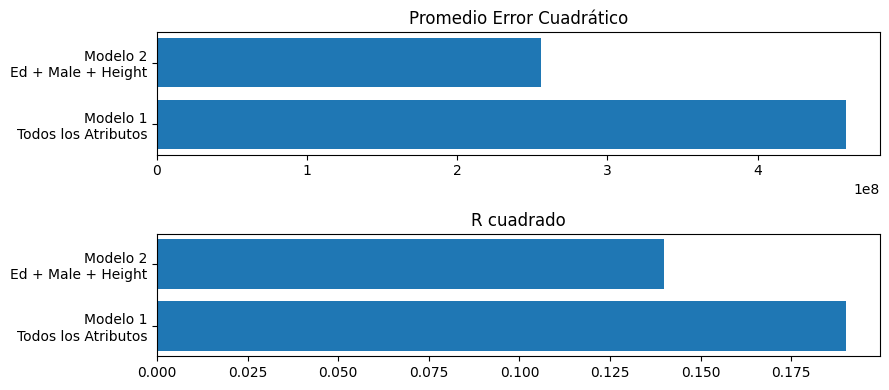

In [27]:
m2_mse = np.round(mean_squared_error(y_test, purge_model_yhat), 0)
m2_r2 = np.round(r2_score(y_test, purge_model_yhat), 2)
plt.subplot(2,1,1)
plt.barh(['Modelo 1\nTodos los Atributos', 'Modelo 2\nEd + Male + Height'], [m1_mse, m2_mse])
plt.title("Promedio Error Cuadrático")
plt.subplot(2,1, 2)
plt.barh(['Modelo 1\nTodos los Atributos', 'Modelo 2\nEd + Male + Height'], [m1_r2, m2_r2])
plt.title("R cuadrado");
plt.tight_layout()

Si comparamos el promedio del error cuadrático para ambos modelos, existe evidencia para preferir el segundo modelo, dado que presenta una reducción significativa del error cuadrático.

Resulta contraintuitivo el hecho que el R cuadrado indica evidencia favorable para el primer modelo.

¿Por qué sucede esto?

Resulta que la forma en que se calcula el R cuadrado no penaliza por la inclusión de variables. En la medida que nosotros agregamos más variables al modelo, el R cuadrado sólo puede aumentar en su "poder explicativo" o mantenerse constante. Este comportamiento engaña el criterio de selección de modelos.

El promedio del error cuadrático hace más sentido para justificar el poder predictivo de un modelo de regresión lineal en el sentido que es una medida directa del método de optimización (mínimos cuadrados ordinarios).